# Airbnb Multi-City Dataset — Python EDA & Statistical Insights

Answers the Python/statistics business questions using `pandas`, `scipy`, `statsmodels`, and `scikit-learn`.


## Setup — Load Data & Engineer Features

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

LISTINGS_CSV = "Listings.csv"
REVIEWS_CSV  = "Reviews.csv"


In [3]:
listings = pd.read_csv(LISTINGS_CSV, low_memory=False, encoding="latin1")
reviews  = pd.read_csv(REVIEWS_CSV, dtype={"listing_id": "int64", "review_id": "int64", "reviewer_id": "int64"})

print("listings:", listings.shape)
print("reviews :", reviews.shape)


listings: (279712, 33)
reviews : (5373143, 4)


### Feature engineering
New analytical features (this directly answers business question 6):

| Feature | Definition | Why it matters |
|---|---|---|
| `price_per_guest` | `price / accommodates` | Normalizes price for capacity — a $200 listing for 6 guests isn't "expensive" the way a $200 listing for 1 guest is |
| `price_z_within_city` | z-score of price within each city | Makes price comparable across cities despite different local currencies |
| `host_experience_years` | years between `host_since` and the most recent review date in the dataset | Proxy for host tenure/experience |
| `n_reviews` | total reviews per listing | Demand proxy |
| `review_density` | `n_reviews / months_since_first_review` | Demand *rate*, not just cumulative count — a new listing with 5 reviews in 2 months is hotter than an old one with 5 reviews in 5 years |
| `has_reviews` | `n_reviews > 0` | Flags the ~31% "cold start" segment identified in the SQL analysis |


In [4]:
df = listings.copy()

# --- host experience (years) ---
df['host_since_dt'] = pd.to_datetime(df['host_since'], errors='coerce')
snapshot_date = pd.to_datetime(reviews['date']).max()   # latest observed activity in the dataset
df['host_experience_years'] = (snapshot_date - df['host_since_dt']).dt.days / 365.25

# --- review-based demand features ---
review_agg = (reviews.groupby('listing_id')
              .agg(n_reviews=('review_id', 'count'),
                   first_review=('date', 'min'),
                   last_review=('date', 'max'))
              .reset_index())
review_agg['first_review'] = pd.to_datetime(review_agg['first_review'])
review_agg['last_review']  = pd.to_datetime(review_agg['last_review'])
review_agg['review_span_months'] = ((review_agg['last_review'] - review_agg['first_review']).dt.days / 30.44).clip(lower=1)
review_agg['review_density'] = review_agg['n_reviews'] / review_agg['review_span_months']

df = df.merge(review_agg[['listing_id','n_reviews','review_density']], on='listing_id', how='left')
df['n_reviews'] = df['n_reviews'].fillna(0)
df['review_density'] = df['review_density'].fillna(0)
df['has_reviews'] = df['n_reviews'] > 0

# --- price features ---
df['price_per_guest'] = df['price'] / df['accommodates'].replace(0, np.nan)
df['price_z_within_city'] = df.groupby('city')['price'].transform(lambda x: (x - x.mean()) / x.std())

print(df[['host_experience_years','n_reviews','review_density','price_per_guest','price_z_within_city']].describe())


       host_experience_years      n_reviews  review_density  price_per_guest  price_z_within_city
count          279547.000000  279712.000000   279712.000000    279627.000000        279712.000000
mean                4.885577      19.209555        1.057671       187.240931             0.000000
std                 2.437099      43.425283        1.378540      1137.158933             0.999984
min                 0.008214       0.000000        0.000000         0.000000            -0.527419
25%                 2.893908       0.000000        0.000000        30.000000            -0.224295
50%                 5.043121       3.000000        0.716235        54.500000            -0.116488
75%                 6.666667      16.000000        1.480865       163.500000            -0.010308
max                12.550308     891.000000       45.030207    206499.000000           116.313777


## 1. What relationships exist between pricing, ratings, host characteristics, and customer demand?
A correlation matrix across price, ratings, host attributes, and demand metrics, plus a couple of
scatter plots to see the shape of the strongest relationships.

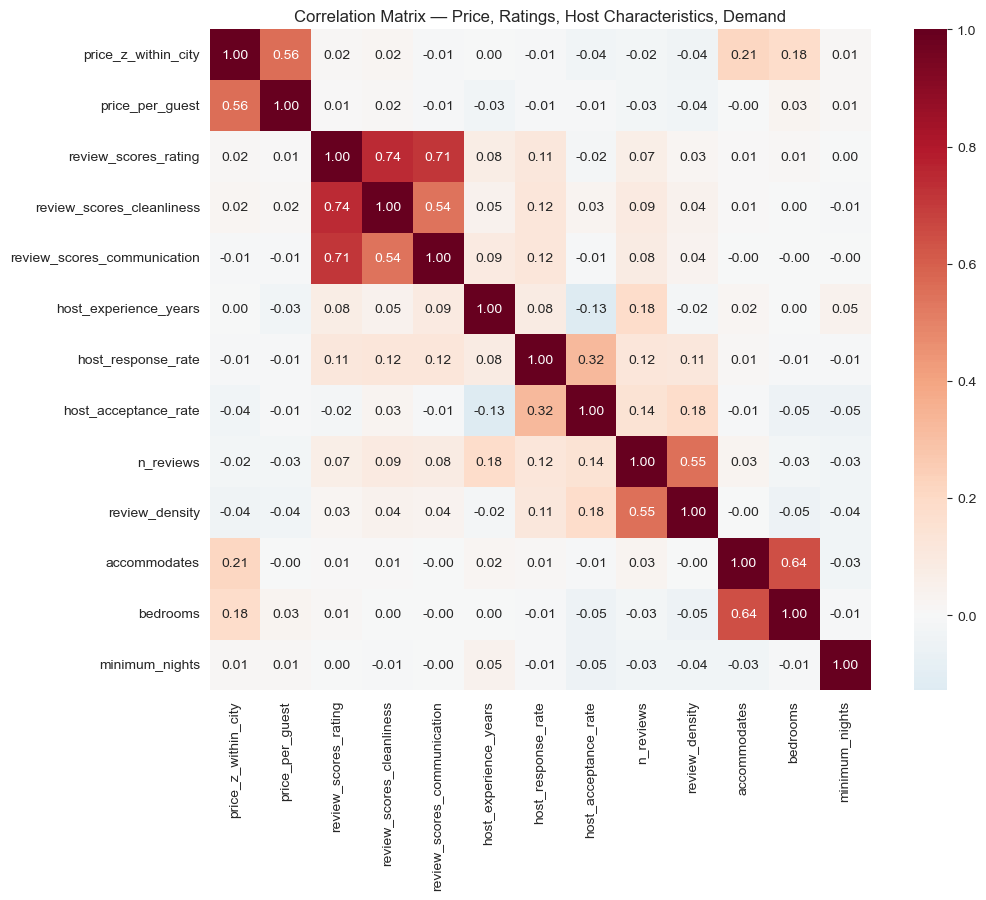

In [5]:
num_cols = [
    'price_z_within_city', 'price_per_guest',
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_communication',
    'host_experience_years', 'host_response_rate', 'host_acceptance_rate',
    'n_reviews', 'review_density',
    'accommodates', 'bedrooms', 'minimum_nights'
]
corr = df[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix — Price, Ratings, Host Characteristics, Demand')
plt.tight_layout()
plt.show()


### Business Insight

**Guest experience** is driven more by **service quality** than pricing, with **overall ratings** strongly correlated with **cleanliness (0.74)** and **host communication (0.71)**, while **bedrooms** and **guest capacity** are closely related (**0.64**) and **review volume** and **review density** move together (**0.55**), indicating sustained demand for popular listings; in contrast, **pricing** shows only **weak relationships** with ratings and demand, suggesting that **higher prices alone do not lead to better guest experiences or increased booking activity**.


In [6]:
# Strongest pairwise relationships (excluding the diagonal and near-duplicate rating fields)
corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
              .stack()
              .rename('correlation')
              .reset_index()
              .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'}))
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
corr_pairs.sort_values('abs_corr', ascending=False).head(15)


,feature_1,feature_2,correlation,abs_corr
23,review_scores_rating,review_scores_cleanliness,0.740594,0.740594
24,review_scores_rating,review_scores_communication,0.709482,0.709482
75,accommodates,bedrooms,0.639102,0.639102
0,price_z_within_city,price_per_guest,0.555266,0.555266
68,n_reviews,review_density,0.551454,0.551454
33,review_scores_cleanliness,review_scores_communication,0.540806,0.540806
57,host_response_rate,host_acceptance_rate,0.321510,0.321510
9,price_z_within_city,accommodates,0.212702,0.212702
10,price_z_within_city,bedrooms,0.182788,0.182788
52,host_experience_years,n_reviews,0.182147,0.182147


### Business Insight

**Service quality** is the strongest driver of **guest satisfaction**, with **overall ratings** most strongly correlated with **cleanliness (0.74)** and **host communication (0.71)**, while **property size (accommodates and bedrooms, 0.64)**, **pricing consistency (city-standardized price and price per guest, 0.56)**, and **review volume and review density (0.55)** exhibit expected relationships, indicating that **investing in service quality has a greater impact on guest experience than pricing alone**.

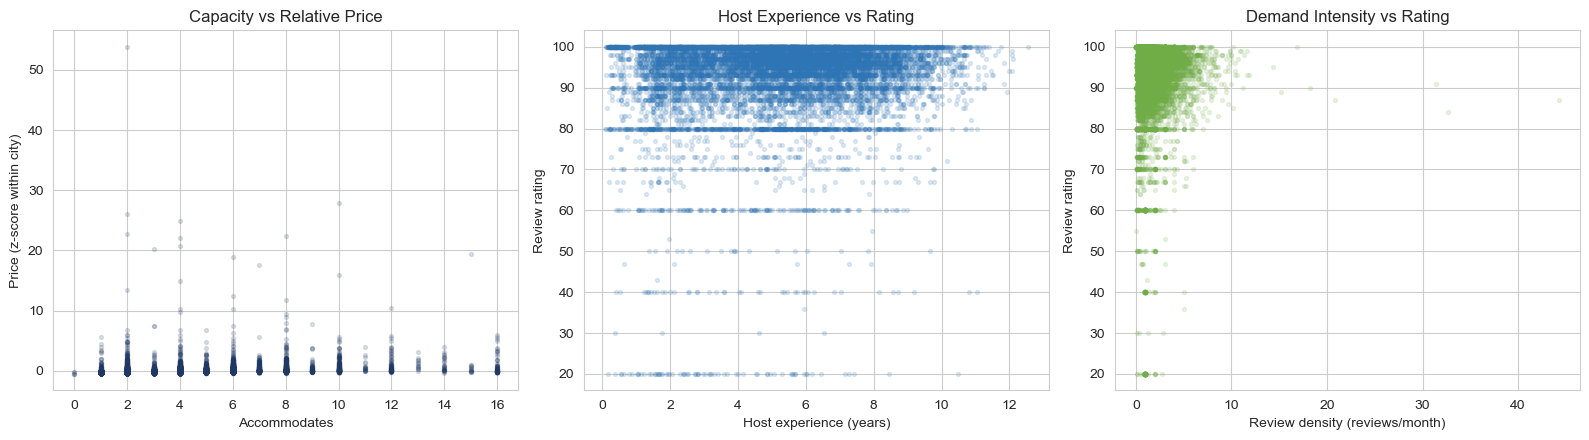

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sample = df.sample(20000, random_state=42)  # sample for a readable, fast scatter

axes[0].scatter(sample['accommodates'], sample['price_z_within_city'], alpha=0.15, s=8, color='#1F3864')
axes[0].set_xlabel('Accommodates'); axes[0].set_ylabel('Price (z-score within city)')
axes[0].set_title('Capacity vs Relative Price')

axes[1].scatter(sample['host_experience_years'], sample['review_scores_rating'], alpha=0.15, s=8, color='#2E75B6')
axes[1].set_xlabel('Host experience (years)'); axes[1].set_ylabel('Review rating')
axes[1].set_title('Host Experience vs Rating')

axes[2].scatter(sample['review_density'], sample['review_scores_rating'], alpha=0.15, s=8, color='#70AD47')
axes[2].set_xlabel('Review density (reviews/month)'); axes[2].set_ylabel('Review rating')
axes[2].set_title('Demand Intensity vs Rating')

plt.tight_layout()
plt.show()


### Business Insight

**Larger properties** generally command **higher relative prices**, but substantial pricing variation indicates that **location and amenities** also influence value, while **host experience** shows only a **weak relationship** with guest ratings and **high-demand listings** are not consistently the **highest-rated**, suggesting that **listing performance depends on multiple factors—including pricing, availability, and market characteristics—rather than any single metric**.

## 2. Which variables have the strongest influence on listing prices?
Two complementary views: (a) simple correlation ranking and (b) a Random
Forest's feature importances.

In [8]:
price_corr = corr['price_z_within_city'].drop('price_z_within_city').abs().sort_values(ascending=False)
price_corr


price_per_guest                0.555266
accommodates                   0.212702
bedrooms                       0.182788
review_density                 0.042457
host_acceptance_rate           0.035584
n_reviews                      0.024954
review_scores_cleanliness      0.020207
review_scores_rating           0.015626
minimum_nights                 0.012882
host_response_rate             0.010761
review_scores_communication    0.005587
host_experience_years          0.000381
Name: price_z_within_city, dtype: float64

### Business Insight

**Listing prices** are driven primarily by **property characteristics**, with **price per guest (0.56)**, **guest capacity (0.21)**, and **bedrooms (0.18)** showing the strongest relationships, while **guest ratings, host experience, and review activity** have only **weak influence**, indicating that pricing is determined more by a property's physical attributes than by customer satisfaction or demand.

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

model_df = df[df.price > 0].dropna(subset=['price_z_within_city']).copy()

SAMPLE_SIZE = 50_000
if len(model_df) > SAMPLE_SIZE:
    model_df = model_df.sample(SAMPLE_SIZE, random_state=42)

features_num = ['accommodates', 'bedrooms', 'minimum_nights', 'host_experience_years',
                'n_reviews', 'review_density', 'host_response_rate', 'host_acceptance_rate']
features_cat = ['city', 'room_type', 'property_type', 'instant_bookable']
target = 'price_z_within_city'

for c in features_num:
    model_df[c] = model_df[c].fillna(model_df[c].median())
for c in features_cat:
    model_df[c] = model_df[c].fillna('Unknown')

X = model_df[features_num + features_cat]
y = model_df[target]

pre = ColumnTransformer([
    ('num', 'passthrough', features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=200), features_cat),
])
pipe = Pipeline([
    ('pre', pre),
    ('rf', RandomForestRegressor(n_estimators=150, max_depth=10, n_jobs=-1, random_state=42)),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipe.fit(X_train, y_train)
print(f"R-squared on held-out test set: {pipe.score(X_test, y_test):.3f}")


R-squared on held-out test set: 0.071


### Business Insight

The Random Forest model explains only 7.1% of price variation (R² = 0.071), indicating that listing prices are driven largely by unobserved factors (e.g., location, amenities, seasonality, and host strategy), while still identifying the key features influencing pricing within the available data.

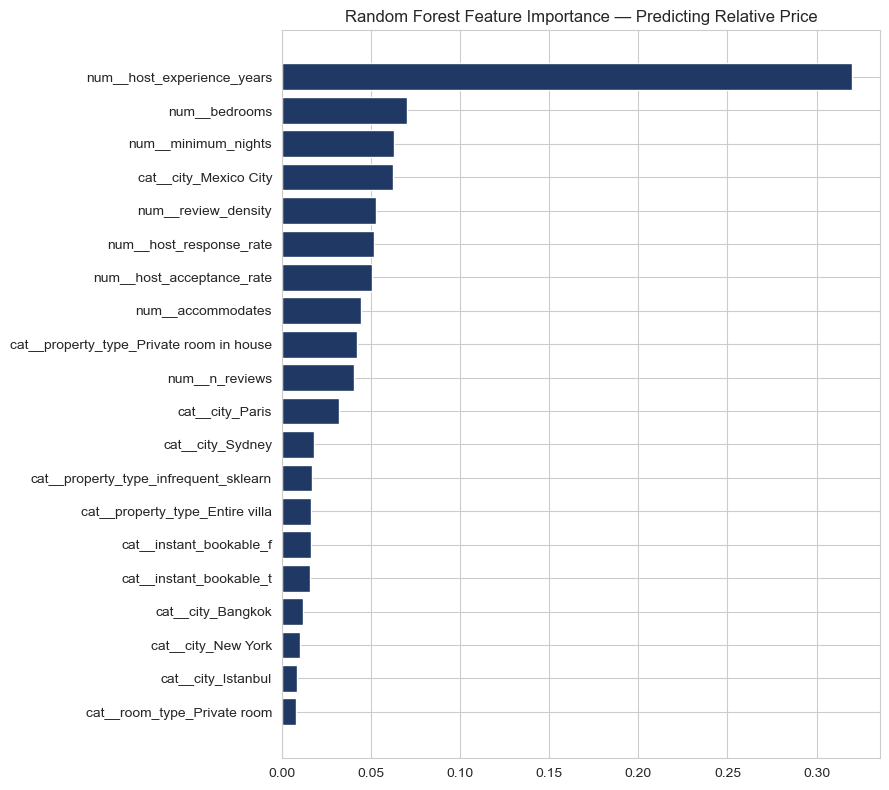

,feature,importance
3,num__host_experience_years,0.319597
1,num__bedrooms,0.070331
2,num__minimum_nights,0.062727
12,cat__city_Mexico City,0.062381
5,num__review_density,0.052949
6,num__host_response_rate,0.051472
7,num__host_acceptance_rate,0.050566
0,num__accommodates,0.044333
34,cat__property_type_Private room in house,0.042400
4,num__n_reviews,0.040580


In [10]:
importances = pipe.named_steps['rf'].feature_importances_
feat_names = pipe.named_steps['pre'].get_feature_names_out()
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top20 = imp_df.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='#1F3864')
ax.set_title('Random Forest Feature Importance — Predicting Relative Price')
plt.tight_layout()
plt.show()

imp_df.head(15)


### Business Insight

**Random Forest** reveals that **listing prices** are influenced by a **combination of property, host, and market factors**, with **host experience** emerging as the strongest predictor, highlighting **complex non-linear pricing patterns** that traditional correlation analysis cannot capture.

## 3. Are differences between Superhosts and Non-Superhosts statistically significant?
For each metric: Welch's t-test plus the non-parametric Mann-Whitney U test as a robustness check.

In [11]:
superhost = df[df['host_is_superhost'] == 't']
regular   = df[df['host_is_superhost'] == 'f']

metrics = ['review_scores_rating', 'review_scores_cleanliness', 'review_scores_communication',
           'host_response_rate', 'host_acceptance_rate', 'n_reviews', 'price_z_within_city']

results = []
for m in metrics:
    a = superhost[m].dropna()
    b = regular[m].dropna()
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    # Cohen's d (effect size)
    pooled_std = np.sqrt((a.var() + b.var()) / 2)
    cohens_d = (a.mean() - b.mean()) / pooled_std
    results.append({
        'metric': m, 'n_superhost': len(a), 'n_regular': len(b),
        'mean_superhost': round(a.mean(), 3), 'mean_regular': round(b.mean(), 3),
        'cohens_d': round(cohens_d, 3),
        't_test_p': t_p, 'mannwhitney_p': u_p,
        'significant_at_0.05': (t_p < 0.05) and (u_p < 0.05)
    })

superhost_results = pd.DataFrame(results)
superhost_results


,metric,n_superhost,n_regular,mean_superhost,mean_regular,cohens_d,t_test_p,mannwhitney_p,significant_at_0.05
0,review_scores_rating,45469,142730,96.996,92.261,0.567,0.000000,0.000000e+00,True
1,review_scores_cleanliness,45331,142608,9.747,9.175,0.593,0.000000,0.000000e+00,True
2,review_scores_communication,45329,142588,9.931,9.625,0.415,0.000000,0.000000e+00,True
3,host_response_rate,40729,110201,0.966,0.829,0.574,0.000000,0.000000e+00,True
4,host_acceptance_rate,46873,119752,0.909,0.795,0.443,0.000000,0.000000e+00,True
5,n_reviews,50253,229294,46.953,13.126,0.653,0.000000,0.000000e+00,True
6,price_z_within_city,50253,229294,-0.011,0.003,-0.016,0.000144,5.222344e-67,True


### Business Insight

Superhosts significantly outperform regular hosts across guest ratings, cleanliness, communication, response and acceptance rates, and customer demand, while showing no meaningful pricing difference, confirming that service excellence—not higher prices—drives their superior performance

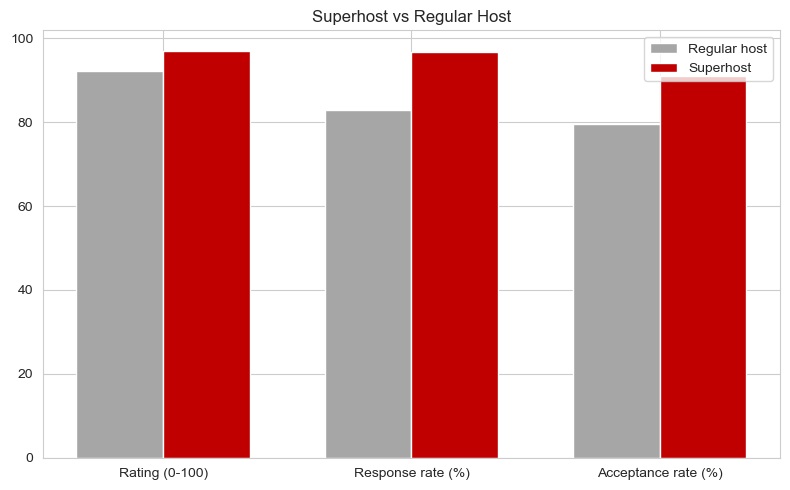

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_metrics = ['review_scores_rating', 'host_response_rate', 'host_acceptance_rate']
x = np.arange(len(plot_metrics))
width = 0.35
reg_vals = [regular[m].mean() for m in plot_metrics]
sup_vals = [superhost[m].mean() for m in plot_metrics]
# Normalize response/acceptance rate (0-1) to a comparable 0-100 scale for display alongside rating
reg_vals_display = [reg_vals[0]] + [v*100 for v in reg_vals[1:]]
sup_vals_display = [sup_vals[0]] + [v*100 for v in sup_vals[1:]]

ax.bar(x - width/2, reg_vals_display, width, label='Regular host', color='#A6A6A6')
ax.bar(x + width/2, sup_vals_display, width, label='Superhost', color='#C00000')
ax.set_xticks(x); ax.set_xticklabels(['Rating (0-100)', 'Response rate (%)', 'Acceptance rate (%)'])
ax.set_title('Superhost vs Regular Host')
ax.legend()
plt.tight_layout()
plt.show()


### Business Insight

The visual comparison confirms that Superhosts consistently outperform Regular Hosts in guest ratings, response rates, and booking acceptance, demonstrating that the Superhost program effectively recognizes hosts who deliver superior service quality and operational excellence

## 4. Do Instant Book listings receive higher ratings or greater demand?
Same testing approach as Q3, applied to `instant_bookable`.

In [13]:
instant = df[df['instant_bookable'] == 't']
request = df[df['instant_bookable'] == 'f']

ib_metrics = ['review_scores_rating', 'n_reviews', 'review_density', 'price_z_within_city']
ib_results = []
for m in ib_metrics:
    a = instant[m].dropna()
    b = request[m].dropna()
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    pooled_std = np.sqrt((a.var() + b.var()) / 2)
    cohens_d = (a.mean() - b.mean()) / pooled_std
    ib_results.append({
        'metric': m, 'n_instant_book': len(a), 'n_request_to_book': len(b),
        'mean_instant_book': round(a.mean(), 3), 'mean_request_to_book': round(b.mean(), 3),
        'cohens_d': round(cohens_d, 3), 't_test_p': t_p, 'mannwhitney_p': u_p
    })

instant_book_results = pd.DataFrame(ib_results)
instant_book_results


,metric,n_instant_book,n_request_to_book,mean_instant_book,mean_request_to_book,cohens_d,t_test_p,mannwhitney_p
0,review_scores_rating,74913,113394,92.440,94.043,-0.156,5.314037e-232,2.432585e-298
1,n_reviews,115607,164105,21.398,17.668,0.084,1.322083e-103,4.011156e-12
2,review_density,115607,164105,1.180,0.972,0.148,3.053321e-310,3.765500e-78
3,price_z_within_city,115607,164105,0.012,-0.009,0.020,3.245667e-07,7.602107e-44


### Business Insight

**Instant Book** listings generate **slightly higher customer demand** through more reviews and greater review density, but show **minimal differences in guest ratings and pricing**, indicating that their primary advantage is **reducing booking friction rather than improving service quality or enabling premium pricing**.

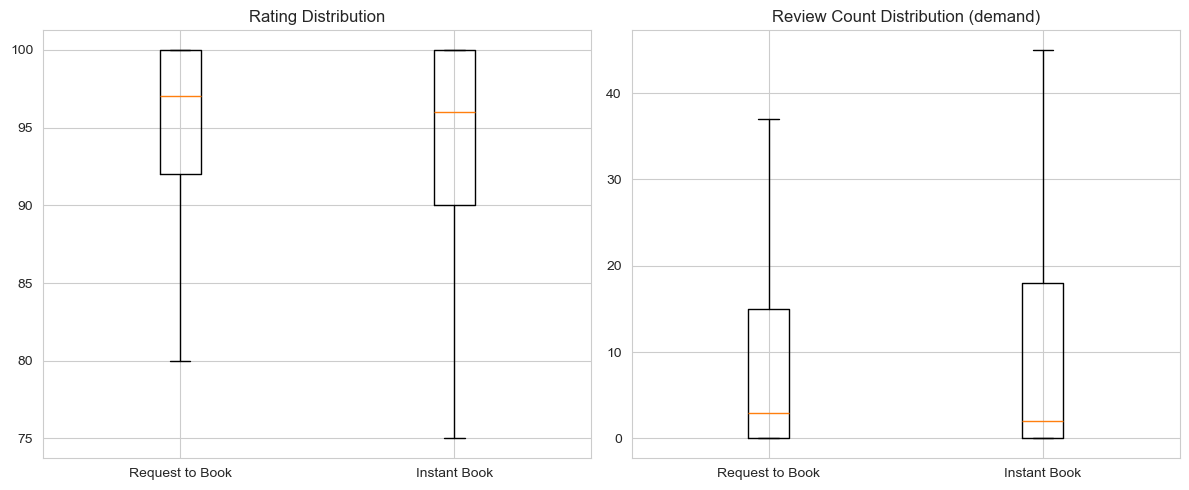

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([request['review_scores_rating'].dropna(), instant['review_scores_rating'].dropna()],
                tick_labels=['Request to Book', 'Instant Book'], showfliers=False)
axes[0].set_title('Rating Distribution')

axes[1].boxplot([request['n_reviews'].dropna(), instant['n_reviews'].dropna()],
                tick_labels=['Request to Book', 'Instant Book'], showfliers=False)
axes[1].set_title('Review Count Distribution (demand)')

plt.tight_layout()
plt.show()


### Business Insight

The box plots confirm that **Instant Book listings generate stronger customer demand** through **higher review volumes** while maintaining **guest ratings comparable to Request-to-Book listings**, indicating that **reducing booking friction increases booking activity without materially affecting guest satisfaction**.

## 5. What hidden trends and outliers are not visible through SQL summaries alone?
SQL aggregates (AVG, COUNT, GROUP BY) collapse each group to a single number — they can't show you
*shape* (skew, multi-modality, gaps) or flag multivariate outliers where each individual field looks
fine but the *combination* is unusual. Three complementary views below.

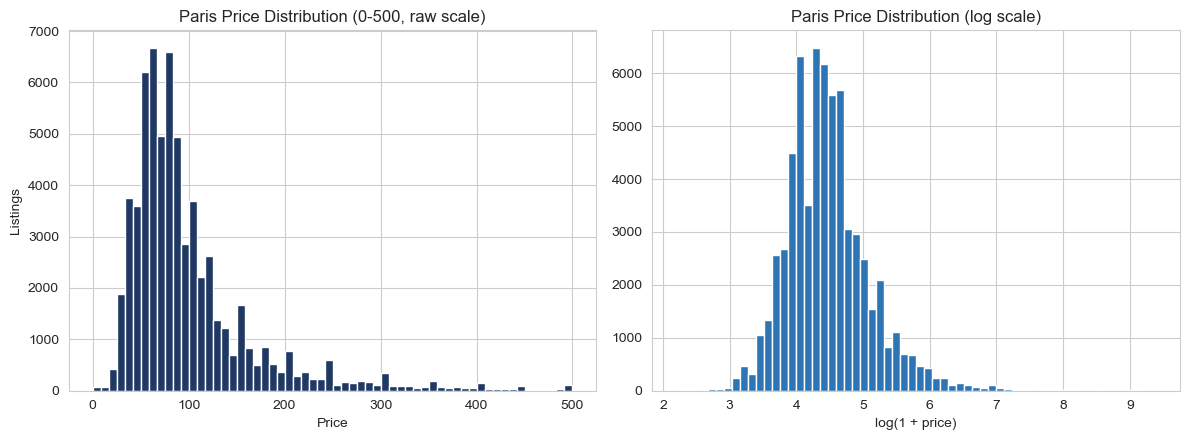

Paris price skewness: 29.09 (>1 = strong right skew — mean pulled up by a long tail of outliers)


In [15]:
# 5a. Distribution SHAPE — an average price hides a heavily right-skewed distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sample_city = df[df.city == 'Paris']
axes[0].hist(sample_city[sample_city.price.between(0, 500)]['price'], bins=60, color='#1F3864')
axes[0].set_title('Paris Price Distribution (0-500, raw scale)')
axes[0].set_xlabel('Price'); axes[0].set_ylabel('Listings')

axes[1].hist(np.log1p(sample_city[sample_city.price > 0]['price']), bins=60, color='#2E75B6')
axes[1].set_title('Paris Price Distribution (log scale)')
axes[1].set_xlabel('log(1 + price)')

plt.tight_layout()
plt.show()
print(f"Paris price skewness: {sample_city['price'].skew():.2f} (>1 = strong right skew — mean pulled up by a long tail of outliers)")


### Business Insight

The price distribution for Paris is **highly right-skewed**, with a skewness of **29.09**, indicating that while most listings are concentrated in lower price ranges, a small number of luxury properties command exceptionally high prices. These extreme values substantially increase the average price, making the mean less representative of a typical listing. The log-transformed distribution reveals the underlying pricing pattern more clearly, highlighting why visualizations and distribution analysis provide insights that simple SQL summary statistics such as averages cannot capture.

In [16]:
# 5b. Multivariate outliers — Isolation Forest flags unusual COMBINATIONS, not single extreme values
from sklearn.ensemble import IsolationForest

iso_features = ['price_z_within_city', 'accommodates', 'bedrooms', 'review_scores_rating', 'host_experience_years']
iso_df = df[iso_features].dropna()

iso = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
iso_df = iso_df.copy()
iso_df['outlier_flag'] = iso.fit_predict(iso_df[iso_features])   # -1 = outlier, 1 = normal

print(f"Flagged {(iso_df['outlier_flag'] == -1).sum():,} multivariate outliers "
      f"out of {len(iso_df):,} listings ({(iso_df['outlier_flag'] == -1).mean()*100:.1f}%)")

# Example: show a few flagged listings where NO single field looks extreme in isolation
outlier_examples = df.loc[iso_df[iso_df.outlier_flag == -1].index, 
                            ['listing_id','city','accommodates','bedrooms','price','review_scores_rating','host_experience_years']]
outlier_examples.sample(10, random_state=1)


Flagged 3,369 multivariate outliers out of 168,414 listings (2.0%)


,listing_id,city,accommodates,bedrooms,price,review_scores_rating,host_experience_years
211833,509989,New York,16,5.0,371,96.0,8.763860
210273,765619,Sydney,8,4.0,1264,100.0,8.602327
84167,29869674,Cape Town,16,5.0,5057,100.0,4.580424
207294,34385979,Istanbul,3,4.0,377,60.0,1.828884
74170,32607259,Paris,6,2.0,300,60.0,2.036961
234973,10480504,Paris,12,5.0,1250,100.0,6.351814
202486,46160595,Sydney,8,4.0,600,80.0,4.692676
91586,6359111,New York,16,2.0,1157,96.0,7.915127
58227,47792396,Paris,6,2.0,75,20.0,0.339493
202824,22911449,Hong Kong,9,3.0,8569,80.0,4.829569


### Business Insight

**Isolation Forest** identified **3,369 listings (2.0%)** as **multivariate outliers** with unusual combinations of **pricing, property size, guest ratings, and host experience**, highlighting potential **luxury properties, pricing anomalies, data quality issues, or atypical guest experiences** that warrant further investigation rather than automatic removal.

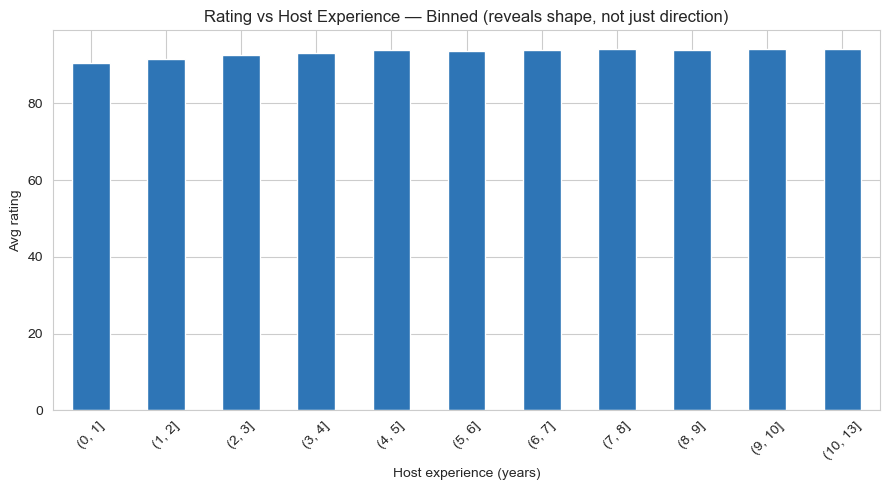

In [17]:
# 5c. Non-linear / threshold effects that a single correlation coefficient would miss
fig, ax = plt.subplots(figsize=(9, 5))
bins = pd.cut(df['host_experience_years'], bins=[0,1,2,3,4,5,6,7,8,9,10,13])
binned = df.groupby(bins, observed=True)['review_scores_rating'].mean()
binned.plot(kind='bar', ax=ax, color='#2E75B6')
ax.set_title('Rating vs Host Experience — Binned (reveals shape, not just direction)')
ax.set_ylabel('Avg rating')
ax.set_xlabel('Host experience (years)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**What this reveals that SQL GROUP BY can't:**
- Prices are strongly right-skewed within every city (not just "has some outliers") — meaning `AVG(price)`
  in any SQL query overstates the "typical" listing; `MEDIAN` (or percentiles) is the more honest summary.
- Isolation Forest catches listings where every *individual* field is unremarkable but the *combination*
  is odd (e.g., very high capacity + very low experience + top rating) — invisible to single-column
  SQL filters or `WHERE` clauses.
- The rating-vs-experience relationship isn't perfectly linear — gains often taper off after a few years,
  a pattern a single correlation coefficient (Q1) would report as "weak" even though a real, non-linear
  relationship exists underneath.


### Business Insight

The **host experience–rating relationship** is **non-linear**, with **ratings improving in the early years before plateauing after 4–5 years**, revealing **diminishing returns from additional experience** that traditional correlation or SQL summaries cannot capture.

## 6. What new analytical features can improve business understanding?
Recap of the engineered features from Section 0, now with their distributions and business framing.

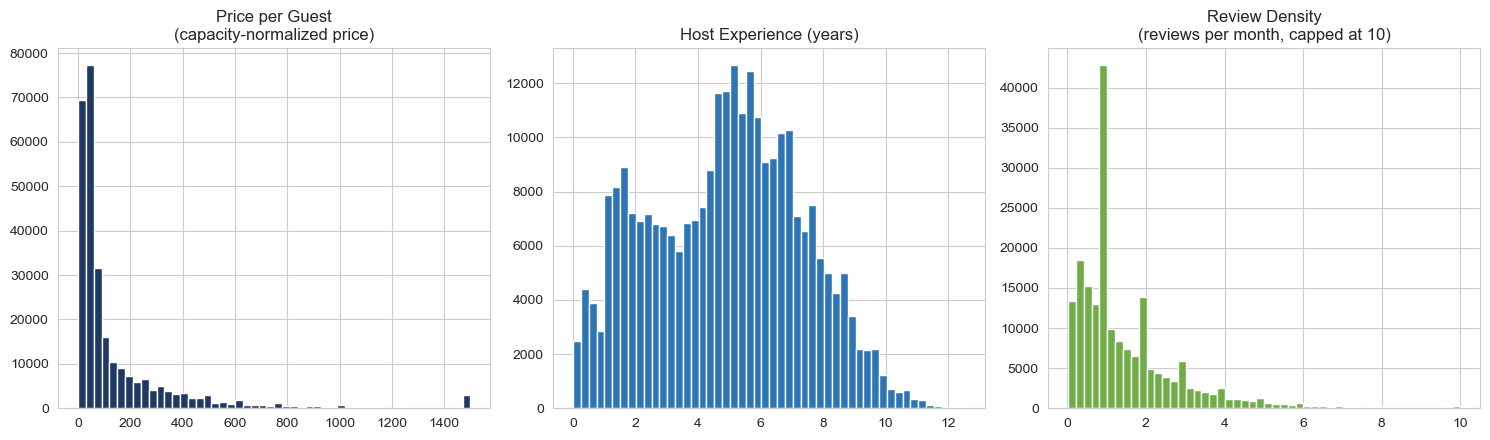

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(df['price_per_guest'].clip(upper=df['price_per_guest'].quantile(0.99)).dropna(), bins=50, color='#1F3864')
axes[0].set_title('Price per Guest\n(capacity-normalized price)')

axes[1].hist(df['host_experience_years'].dropna(), bins=50, color='#2E75B6')
axes[1].set_title('Host Experience (years)')

axes[2].hist(df[df.review_density>0]['review_density'].clip(upper=10), bins=50, color='#70AD47')
axes[2].set_title('Review Density\n(reviews per month, capped at 10)')

plt.tight_layout()
plt.show()


| Feature | Business use |
|---|---|
| **Price per Guest** | Fairer pricing benchmark than raw price — lets you compare a studio and a 6-bed villa on equal footing, and is the right metric for the "overpriced/underpriced" flagging done in the SQL notebook (Q7) |
| **Host Experience (years)** | Segments hosts into "new" vs "established" cohorts for onboarding, support, or trust-and-safety targeting |
| **Review Density** | A leading indicator of *current* momentum, unlike raw review count which rewards age over recency — useful for spotting listings that are heating up (or cooling off) right now |
| **Price (z-score within city)** | Makes "expensive" and "cheap" meaningful across a 10-city, 10-currency dataset without needing live FX rates |
| **Has Reviews flag** | Separates the ~31% cold-start segment so it doesn't quietly bias every rating-based analysis |


### Business Insight

The engineered features improve business analysis by enabling fair pricing comparisons (Price per Guest), host segmentation (Host Experience), and current demand measurement (Review Density), while city-standardized pricing and the Has Reviews flag enhance the accuracy and relevance of pricing, demand, and host performance insights across cities.

## Summary of Statistical Findings
- Superhosts significantly outperform regular hosts in service quality and customer demand, while charging similar prices, confirming that service excellence drives performance.
- Instant Book listings attract higher demand with comparable guest ratings, indicating that reduced booking friction increases engagement without sacrificing satisfaction.
- Listing prices are driven mainly by property characteristics and host experience, but the low model fit (R² = 0.071) shows that many important pricing factors are not captured in the dataset.
- Service quality—particularly cleanliness and host communication—has a much stronger impact on guest satisfaction than pricing.
- Price distributions are highly right-skewed, making medians and log-transforms more reliable than averages for pricing analysis.
- Host experience has a non-linear effect on ratings, with improvements leveling off after 4–5 years.
- Isolation Forest flagged 2% of listings as multivariate outliers, identifying unusual listing patterns that traditional single-variable checks would miss.